---
title: "expectation"
execute:
  # echo: false
  freeze: auto  # re-render only when source changes
format:
  html:
    code-fold: true
    code-summary: "Show the code"
---

The expectation is probably one of the most fundamental concepts in statistics. In simple language, it quantifies the typical value of a random variable. In mathematical language, we write the expectation of a random variable $X$ as $E[X]$.


## definition

If I know the probability distribution of $X$, I can calculate the expectation of $X$ using the following formula:

$$
E[X] = \sum_{x\in \operatorname{supp}(X)} x f_X(x)
$$

for discrete random variables, and

$$
E[X] = \int_{\operatorname{supp}(X)} x f_X(x) dx
$$

for continuous random variables.

Using two of the examples from the previous chapter, we can calculate the expectation of the random variable $X$ that represents the outcome of a die roll, and the expectation of the random variable $H$ that represents the height of an adult male.

### die roll

For the die roll, the probability mass function $f_X(x)$ is given by:

$$
f_X(x) = \frac{1}{6}, \quad x \in \{1, 2, 3, 4, 5, 6\}
$$

and the expectation is:

\begin{align*}
E[X] &= \sum_{x=1}^{6} x f_X(x) \\
&= \sum_{x=1}^{6} x \cdot \frac{1}{6} \\
&= \frac{1}{6} \sum_{x=1}^{6} x \\
&= \frac{1}{6} \cdot 21 \\
&= 3.5
\end{align*}

We can say in words: "the expectation (or expected value) of the outcome of a die roll is 3.5". This means that if we were to roll a die *many times* and calculate the average of the outcomes, we would expect that average to be close to 3.5.

Two comments:

* The expectation does not have to be a value that the random variable can actually take. In the die roll case, the expectation is 3.5, which is not a possible outcome of a die roll.
* I wrote "many times" in the previous paragraph. This is because we use the probability distribution to calculate the expectation, and this distribution describes a population. This sentence is incomprehensible at this point, but I just wanted to point that out and say that I will expand on that in the next chapter.

### height

For the height of an adult male, we assume a normal distribution with two parameters: *location* $\mu$ and *scale* $\sigma$. The probability density function $f_H(h)$ is given by:

$$
f_H(h) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2} \left(\frac{h - \mu}{\sigma}\right)^2}
$$

and the expectation is:

$$
E[H] = \int_{-\infty}^{\infty} h f_H(h) dh.
$$

A suitable substitution of variables is $u = (h-\mu)/\sigma$, which yields: $du=dh/\sigma$ and $h=\sigma u+\mu$.

\begin{align*}
E[H] &= \int_{-\infty}^{\infty} h f_H(h) dh \\
&= \int_{-\infty}^{\infty} h \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2} \left(\frac{h - \mu}{\sigma}\right)^2} dh \\
&= \int_{-\infty}^{\infty} (\sigma u+\mu)\frac{1}{\sqrt{2\pi}} e^{-\frac{1}{2}u^2}du \\
&= \underbrace{\int_{-\infty}^{\infty} \sigma u \frac{1}{\sqrt{2\pi}}e^{-\frac{1}{2}u^2}du}_{\text{term 1}} + \mu \underbrace{\int_{-\infty}^{\infty} \frac{1}{\sqrt{2\pi}}e^{-\frac{1}{2}u^2}du}_{\text{term 2}}
\end{align*}

* term 1: this is an integral over a symmetric domain (from $-\infty$ to $+\infty$) of the product of an odd function ($u$) and an even function ($e^{-u^2}$), therefore term 1 is zero.
* term 2: pay attention, I did not include $\mu$ in term 2. This integral evaluates to $1$.

So we found out that 

$$
E[H] = \mu
$$

In words, we say that the expected value of the height of an adult male is $\mu$, which we call the mean.

## weighted average

In the example of the die roll, $E[X]=3.5$, which is simply the regular mean of all the possible values $X$ can have. This is a regular average because in this particular case, the die is fair, and every outcome has equal weight.

In a more general example, such as the height of adult males, not every height should be considered equally when computing the expectation. There are a lot fewer men whose height is between 160 and 165 cm than between 175 and 180 cm, see the graph below.

In [1]:
#| code-summary: "import libraries"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
#| code-summary: "load data"
df_boys = pd.read_csv('../archive/data/height/boys_height_stats.csv', index_col=0)
mu_boys = df_boys.loc[20.0, 'mu']
sigma_boys = df_boys.loc[20.0, 'sigma']

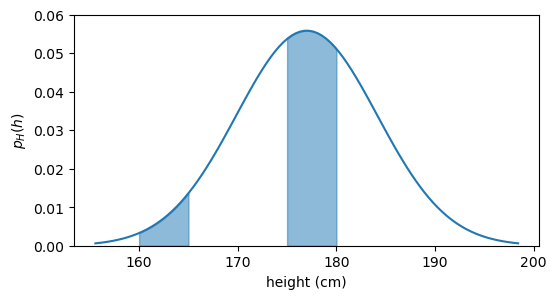

In [5]:
#| code-summary: "plot pdf"
fig, ax = plt.subplots(figsize=(6, 3))
h = np.linspace(mu_boys - 3*sigma_boys, mu_boys + 3*sigma_boys, 100)
h1 = np.linspace(160, 165, 100)
h2 = np.linspace(175, 180, 100)
pdf = norm.pdf(h, loc=mu_boys, scale=sigma_boys)
pdf1 = norm.pdf(h1, loc=mu_boys, scale=sigma_boys)
pdf2 = norm.pdf(h2, loc=mu_boys, scale=sigma_boys)


ax.plot(h, pdf, color="tab:blue")
ax.fill_between(h1, pdf1, alpha=0.5, color="tab:blue")
ax.fill_between(h2, pdf2, alpha=0.5, color="tab:blue")
ax.set(xlabel='height (cm)',
       ylabel=r'$p_H(h)$',
       ylim=(0, 0.06),
      );

When we write

$$
E[H] = \int_{-\infty}^{\infty} h f_H(h) dh,
$$

we are saying that we take into consideration every possible height $h$, but we give more weight to heights that are more common (i.e., have higher $f_H(h)$) and less weight to heights that are less common (lower $f_H(h)$). So the expectation is a weighted average, and the weights are given by the probability distribution.

Another interpretation that is less common in statistics but it is absolutely the same concept, is that the expectation is the **center of mass** of the probability distribution. If the pdf were a physical object (imagine a uniform metal sheet shaped like the probability density above), the expectation would be the point at which you can balance it on the tip of a pencil.

## $E[\text{anything}]$

Say that, for whatever reason, I'm interested in the expectation of the square of the outcome of a die roll ($E[X^2]$), or in the expectation of the square of the height of a person ($E[H^2]$). Can I calculate that? Yes, no problem at all. In the discrete and continuous cases, I just apply the formulas below:

\begin{align*}
E[X^2] &= \sum_{x} x^2 f_X(x)  \tag{LOTUS 1} \\
E[H^2] &= \int_{-\infty}^{\infty} h^2 f_H(h) dh
\tag{LOTUS 2}
\end{align*}

(I'll explain the name LOTUS in a moment...)

This makes sense, I'm only updating the original formulas by replacing $x$ with $x^2$ and $h$ with $h^2$. But there's more to that than meets the eye.

I can think of the square of the outcome of a die roll as a new random variable, let's call it $K$. So $K=X^2$. Since $K$ is a random variable in its own right, I can the definition to calculate its expectation:

$$
E[K] = \sum_{k} k f_K(k).
$$

I have a problem now. I know that every $k$ is the square of some $x$, but I don't know what the probability distribution of $K$ is, i.e., I don't know $f_K(k)$. So how can I calculate $E[K]$?

The "Law Of The Unconscious Statistician" (LOTUS) comes to the rescue. It allows us not to fret about the probability distribution of $K$ and calculate its expectation directly from the probability distribution of $X$ and the function that defines $K$. Let's call $g$ the function that takes $X$ and squares it, so we have that $K=g(X) = X^2$. So when we write $E[K]$, we can do the following:

$$
E[K] = E[g(X)] = \sum_{x} g(x) f_X(x) = \sum_{x} x^2 f_X(x),
$$

and that is exactly what we wrote in the LOTUS 1 formula above. The same applies to the continuous case, which is what we wrote in the LOTUS 2 formula above.

What seemed absolutely straighforward a moment ago, now seems strange. What justifies using $f_X(x)$ as the weights in the expectation of another random variable $K$, whose true probability distribution $f_K(k)$ we don't even know?

I'll prove why this is true in a few more lines. For now, I need us to actually compute $E[X^2]$ using the LOTUS formula, to get a sense of how it works. What is the expectation of the square of the outcome of a die roll?

\begin{align*}
E[X^2] &= \sum_{x} g(x) f_X(x) \\
&= \sum_{x=1}^{6} x^2 \cdot \frac{1}{6} \\
&= \frac{1}{6} \sum_{x=1}^{6} x^2 \\
&= \frac{1}{6} \cdot 91 \\
&\sim 15.16
\end{align*}

## proof of LOTUS

I'll prove LOTUS for the discrete case, using the random variables $X$ and $Y$ from the previous chapter. $X$ was simply the outcome of a die roll, and $Y$ is the parity of the outcome of a die roll, so it maps the outcomes $\{1,3,5\}$ to "odd" and the outcomes $\{2,4,6\}$ to "even". I'll replace the values "odd" and "even" with numbers, so that we can do the calculations: "odd" will be 1 and "even" will be 0. As a result, the support of $Y$ is $\{0,1\}$. Let's write explicitly both $X$ and $Y$:

::: {.column-margin}
I won't use the example $K=g(X)=X^2$ because this will give me a one-to-one mapping between $X$ and $K$, which will make the proof trivial. I want to use the example of $Y=g(X)$ because this will give me a many-to-one mapping between $X$ and $Y$, which will make the proof more interesting.
:::

$$
X:\quad
\begin{matrix}
1 &\longrightarrow & 1 \\
2 &\longrightarrow & 2 \\
3 &\longrightarrow & 3 \\
4 &\longrightarrow & 4 \\
5 &\longrightarrow & 5 \\
\underbrace{6}_{\text{outcome}} &\longrightarrow & \underbrace{6}_{\operatorname{supp}(X)} \\
\end{matrix}
\qquad
Y:\quad
\begin{matrix}
1 &\longrightarrow & 1 \\
2 &\longrightarrow & 0 \\
3 &\longrightarrow & 1 \\
4 &\longrightarrow & 0 \\
5 &\longrightarrow & 1 \\
\underbrace{6}_{\text{outcome}} &\longrightarrow & \underbrace{0}_{\operatorname{supp}(Y)} \\
\end{matrix}
$$

Since the outcomes of the die roll $Y$ operates on are the same as the support of $X$, we can say that $Y$ is a function of $X$:

$$
\begin{matrix}
1\\
2\\
3\\
4\\
5\\
\underbrace{6}_{\text{outcome}}
\end{matrix}
\underset{X}{\longrightarrow}
\begin{matrix}
1\\
2\\
3\\
4\\
5\\
\underbrace{6}_{\operatorname{supp}(X)}
\end{matrix}
\underset{Y=g(X)}{\longrightarrow}
\begin{matrix}
1\\
0\\
1\\
0\\
1\\
\underbrace{0}_{\operatorname{supp}(Y)}
\end{matrix}
\tag{important}
$$

When we wrote $Y=g(X)$ in the equation above, you can think of $g$ as the operation that takes an integer and outputs the remainder when dividing that integer by 2.

We're finally ready to ask: what is $E[Y]$? Let's use the definition of expectation:

$$
E[Y] = \sum_{y\in \operatorname{supp}(Y)} y f_Y(y).
$$

What we need now is to find $f_Y(y)$. We are dealing with the discrete case, so we just have to check the probability of $Y$ being each of the values in its support. $Y$ can be 0 or 1, so we need to check $P(Y=0)$ and $P(Y=1)$. 

The probability of each element in the support of $X$ is $1/6$, so it's obvious that the probability that each **row** in the $\operatorname{supp}(Y)$ in the equation labeled "important" above is also $1/6$. Taking the remainder changes only the numerical value, but not the probability of each row. What we need, however is $P(Y=0)$ and $P(Y=1)$, let's spell them out:

\begin{align*}
P(Y=0) &= \underbrace{P(X=2)}_{1/6} + \underbrace{P(X=4)}_{1/6} + \underbrace{P(X=6)}_{1/6} = \frac{1}{2} \\
P(Y=1) &= \underbrace{P(X=1)}_{1/6} + \underbrace{P(X=3)}_{1/6} + \underbrace{P(X=5)}_{1/6} = \frac{1}{2}
\end{align*}

Of course, we can **see** that half of the rows in the $\operatorname{supp}(Y)$ are 0 and half of them are 1, so we could have just said that $P(Y=0)=P(Y=1)=1/2$ without doing the calculations. But in more complex cases, we won't be able to see that. In those cases, we will write the general formula for $P(Y=y)$, which is:

$$
P(Y=y) = \sum_{x: g(x)=y} P(X=x).
$$

In words: to calculate the probability of $Y$ being a certain value $y$, we need to sum the probabilities of all the values in the support of $X$ that are mapped to $y$ by the function $g$. Read that a couple of times and convince yourself that this is exactly what we did in the intuitive calculation of $P(Y=0)$ and $P(Y=1)$ above.

Because the equation above has general $y$ and $x$ values, instead of writing the capital $P$ for probability, we can write the lowercase $f$ for probability mass function:

$$
f_Y(y) = \sum_{x: g(x)=y} f_X(x).
$$

Now that we have an expression for $f_Y(y)$, we can plug it into the definition of expectation:

\begin{align*}
E[Y] &= \sum_{y\in \operatorname{supp}(Y)} y f_Y(y) \tag{L1} \\
&= \sum_{y\in \operatorname{supp}(Y)} y \sum_{x: g(x)=y} f_X(x) \tag{L2} \\
&= \sum_{y\in \operatorname{supp}(Y)}\,\,\, \sum_{x: g(x)=y} y f_X(x) \tag{L3} \\
&= \underbrace{\sum_{y\in \operatorname{supp}(Y)}}_{\text{loop 1}}\,\,\, \underbrace{\sum_{x: g(x)=y}}_{\text{loop 2}} g(x) f_X(x) \tag{L4}
\end{align*}

Let's understand what we did here:

* L1: this is the definition of expectation.
* L2: we plugged in the expression for $f_Y(y)$ that we found above.
* L3: we put $y$ inside the inner sum, since it does not depend on $x$.
* L4: we replaced $y$ with $g(x)$, since $y=g(x)$ by definition.

We are left with a very ugly double sum! How to make sense of it?

Taking inspiration from [Freya Holmér's post on X](https://x.com/FreyaHolmer/status/1436696408506212353), the summation symbol can be thought of as a "for loop".

![](for-loops.png)

I called each summation symbol "loop 1" and "loop 2". I will now translate equation L4 into Python code:

In [ ]:
#| code-fold: false
x = np.array(
    [
        [2, 4, 6],   # these give remainder of 0
        [1, 3, 5],   # these give remainder of 1
    ]
)
g = lambda x: x % 2  # remainder function
E = 0
for row in x:                     # loop 1
    for element in row:           # loop 2
        E += g(element) * (1/6)   # g(x)*f_X(x)
print(f"E[Y] = E[g(X)] = {E}")

E[Y] = E[g(X)] = 0.5


What becomes patently obvious from the double loop in the code is that the double summation is simply iterating over all the values in $X$:

$$
E[Y] = \sum_{x\in \operatorname{supp}(X)} g(x) f_X(x),
$$

which in code simply becomes:

In [ ]:
#| code-fold: false
supp_x = np.array([1,2,3,4,5,6])
E = 0
for x in supp_x:
    E += g(x) * (1/6)

And that proves LOTUS for the discrete case. The proof for the continuous case is left as an exercise for the reader 😈.